In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
from itertools import product
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [2]:
# GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
df_stamps = pd.read_pickle("alerce_stamps/stamps_onecandid.pkl")
# index es oid
df_stamps = df_stamps.set_index("oid")

In [125]:
df_stamps.head()

,candid,difference,science,template,label
oid,,,,,
ZTF17aaaeqms,2333478931915015006,"[[1.0580313, 22.326302, 0.6676886, 9.657951, -...","[[105.624146, 126.8667, 106.02069, 113.787415,...","[[103.50632, 103.856895, 105.12142, 103.89225,...",bad
ZTF17aaaeucx,2940111751315015018,"[[-0.33186716, 4.095159, -1.8843734, 1.0711339...","[[166.33603, 170.92786, 168.14435, 166.1821, 1...","[[167.57974, 168.07402, 168.1266, 167.8712, 16...",bad
ZTF17aaakbyl,2970134564615015219,"[[-15.354166, -4.040905, 3.2129498, -55.157394...","[[305.2724, 335.36346, 324.74908, 322.62134, 3...","[[326.33936, 333.94037, 341.88602, 351.33307, ...",good
ZTF17aaakyau,2953477283615015059,"[[26.94304, 9.3317585, -10.536246, 23.698849, ...","[[575.74255, 546.9619, 551.3667, 564.05444, 53...","[[544.12054, 545.9207, 557.119, 544.63, 547.34...",bad
ZTF17aaapmss,2498535436315015000,"[[-1.5437337, -14.555921, -14.323448, 26.64250...","[[246.93246, 230.01614, 235.26596, 267.1912, 2...","[[244.9367, 243.68794, 243.59225, 244.37834, 2...",bad


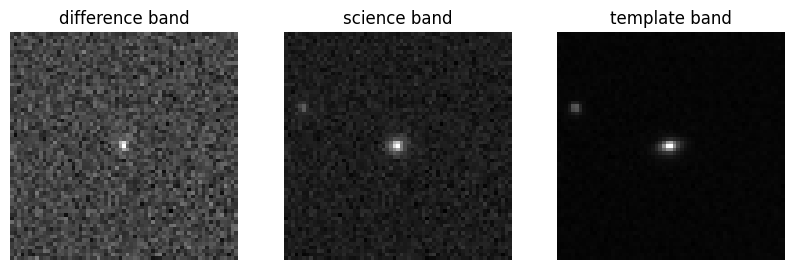

In [126]:
# plot oid de ejemplo
# difference	science	template
# ploteamos los 3 STAMPS de un oid de ejemplo
example_oid = "ZTF17aaapmss"
plt.figure(figsize=(10, 5))
for band in ["difference", "science", "template"]:
    plt.subplot(1, 3, ["difference", "science", "template"].index(band) + 1)
    plt.imshow(df_stamps.loc[example_oid][band], cmap="gray")
    plt.title(f"{band} band")
    plt.axis("off")

In [4]:
# mapeo de etiquetas a enteros
label_map = {'bad': 0, 'good': 1}
labels = df_stamps['label'].map(label_map).values

In [5]:
# extraemos las dimensiones de los stamps
TARGET_H, TARGET_W =30, 30
N = len(df_stamps)
print(f"Dimensiones de los stamps: {TARGET_H}x{TARGET_W}, Número de stamps: {N}")

Dimensiones de los stamps: 30x30, Número de stamps: 19730


In [6]:
# contenedor para el tensor
data_np = np.zeros((N, 3, TARGET_H, TARGET_W), dtype=np.float32)

In [7]:
def center_crop_or_pad(img, target_h, target_w):
    """
    Recorta o paddea un array 2D alrededor del centro para que quede de tamaño (target_h, target_w).
    - Si img es más grande: recorta.
    - Si img es más pequeño: paddea con ceros.
    """
    # Verificar que la imagen no tenga NaN
    if np.isnan(img).any():
        print(f"WARNING: Input image contains NaN values, shape: {img.shape}")
        img = np.nan_to_num(img, nan=0.0)
    
    h, w = img.shape
    
    # Calcular centro
    cy, cx = h // 2, w // 2
    
    # Calcular límites del recorte en la imagen destino
    start_y = max(0, target_h//2 - cy)
    end_y = min(target_h, start_y + h)
    start_x = max(0, target_w//2 - cx)
    end_x = min(target_w, start_x + w)
    
    # Calcular límites del recorte en la imagen origen
    src_start_y = max(0, cy - target_h//2)
    src_end_y = src_start_y + (end_y - start_y)
    src_start_x = max(0, cx - target_w//2)
    src_end_x = src_start_x + (end_x - start_x)
    
    # Crear imagen de salida inicializada con ceros
    output = np.zeros((target_h, target_w), dtype=img.dtype)
    
    # Copiar la parte relevante de la imagen
    output[start_y:end_y, start_x:end_x] = img[src_start_y:src_end_y, src_start_x:src_end_x]
    
    return output

In [8]:
print("\n=== Verificando función center_crop_or_pad ===")
test_img = np.random.randn(50, 50)
result = center_crop_or_pad(test_img, TARGET_H, TARGET_W)
print(f"Input shape: {test_img.shape}, Output shape: {result.shape}")
print(f"NaNs in result: {np.isnan(result).any()}")


=== Verificando función center_crop_or_pad ===
Input shape: (50, 50), Output shape: (30, 30)
NaNs in result: False


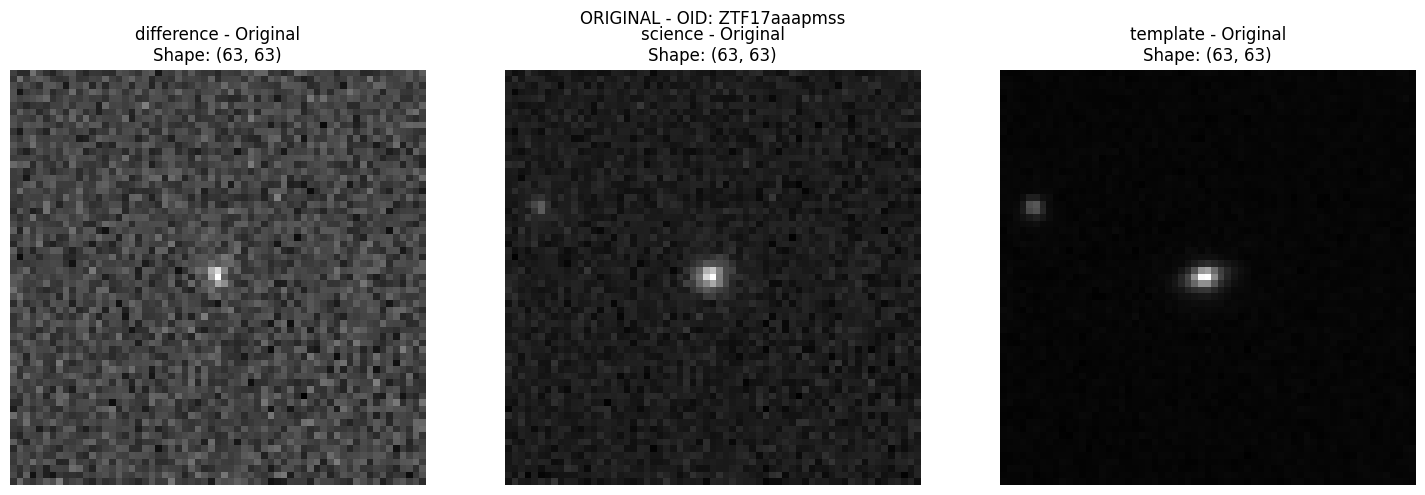

In [21]:
example_oid = "ZTF17aaapmss"
if example_oid in df_stamps.index:
    plt.figure(figsize=(15, 5))
    for i, band in enumerate(["difference", "science", "template"]):
        plt.subplot(1, 3, i + 1)
        img = df_stamps.loc[example_oid][band]
        plt.imshow(img, cmap="gray")
        plt.title(f"{band} - Original\nShape: {img.shape}")
        plt.axis("off")
    plt.suptitle(f"ORIGINAL - OID: {example_oid}")
    plt.tight_layout()
    plt.show()

In [9]:
# K folds estratisficados
splits = pd.read_csv('folds/stratified_folds_stamps.csv')  

In [10]:
def get_fold_indices(df, fold):
    train_col = f'train_fold{fold}'
    val_col   = f'val_fold{fold}'
    train_idx = df.loc[df[train_col]==1, 'orig_idx'].tolist()
    val_idx   = df.loc[df[val_col]==1,   'orig_idx'].tolist()
    return train_idx, val_idx

In [11]:
df_indexed = df_stamps.reset_index(drop=False) 
df_indexed['orig_idx'] = df_indexed.index

In [12]:
# Juntamos los datos con el split
df_merged = df_indexed.merge(splits, on='oid', how='inner')
assert len(df_merged) == N, f"Mismatch: df_merged has {len(df_merged)} rows, expected {N}"

In [141]:
df_merged.head()

,oid,candid,difference,science,template,label,orig_idx,test,train_fold1,val_fold1,train_fold2,val_fold2,train_fold3,val_fold3,train_fold4,val_fold4,train_fold5,val_fold5
0,ZTF17aaaeqms,2333478931915015006,"[[1.0580313, 22.326302, 0.6676886, 9.657951, -...","[[105.624146, 126.8667, 106.02069, 113.787415,...","[[103.50632, 103.856895, 105.12142, 103.89225,...",bad,0,0,1,0,0,1,1,0,1,0,1,0
1,ZTF17aaaeucx,2940111751315015018,"[[-0.33186716, 4.095159, -1.8843734, 1.0711339...","[[166.33603, 170.92786, 168.14435, 166.1821, 1...","[[167.57974, 168.07402, 168.1266, 167.8712, 16...",bad,1,0,1,0,1,0,1,0,1,0,0,1
2,ZTF17aaakbyl,2970134564615015219,"[[-15.354166, -4.040905, 3.2129498, -55.157394...","[[305.2724, 335.36346, 324.74908, 322.62134, 3...","[[326.33936, 333.94037, 341.88602, 351.33307, ...",good,2,0,1,0,1,0,1,0,0,1,1,0
3,ZTF17aaakyau,2953477283615015059,"[[26.94304, 9.3317585, -10.536246, 23.698849, ...","[[575.74255, 546.9619, 551.3667, 564.05444, 53...","[[544.12054, 545.9207, 557.119, 544.63, 547.34...",bad,3,0,1,0,1,0,1,0,1,0,0,1
4,ZTF17aaapmss,2498535436315015000,"[[-1.5437337, -14.555921, -14.323448, 26.64250...","[[246.93246, 230.01614, 235.26596, 267.1912, 2...","[[244.9367, 243.68794, 243.59225, 244.37834, 2...",bad,4,1,0,0,0,0,0,0,0,0,0,0


In [13]:
# rellenamos el tensor con los datos de los stamps
print("\n=== Procesando stamps ===")
nan_count = 0
fixed_count = 0

for i, (_, row) in enumerate(df_merged.iterrows()):
    oid = row['oid']  # ahora oid es una columna, no el índice
    candid = row['candid']
    orig_idx = row['orig_idx']  # índice original en el dataframe
    
    for chan, kind in enumerate(['difference','science','template']):
        img = row[kind]             # np.ndarray de tamaño variable
        
        # Verificar NaN antes del procesamiento
        if np.isnan(img).any():
            nan_count += 1
            print(f"NaN found in {oid}, {kind}")
        
        # comprueba si necesita recorte/padding
        if img.shape != (TARGET_H, TARGET_W):
            original_shape = img.shape
            img_fixed = center_crop_or_pad(img, TARGET_H, TARGET_W)
            fixed_count += 1
            if i < 5:  # Solo mostrar los primeros 5 para debug
                print(f"[FIXED] OID={oid}, candid={candid}, canal={kind}, "
                      f"original_shape={original_shape} → new_shape={img_fixed.shape}")
        else:
            img_fixed = img
        
        # Asegurarse de que no hay NaN en el resultado final
        if np.isnan(img_fixed).any():
            print(f"WARNING: NaN in processed image for {oid}, {kind}")
            img_fixed = np.nan_to_num(img_fixed, nan=0.0)
        
        # Verificar y limpiar valores extremos
        if np.isinf(img_fixed).any():
            print(f"WARNING: Inf values in processed image for {oid}, {kind}")
            img_fixed = np.nan_to_num(img_fixed, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Detectar valores extremos que pueden causar overflow
        extreme_mask = (np.abs(img_fixed) > 1e10)
        if extreme_mask.any():
            print(f"WARNING: Extreme values in {oid}, {kind}: "
                  f"min={img_fixed.min():.3e}, max={img_fixed.max():.3e}")
            # Reemplazar valores extremos con 0
            img_fixed[extreme_mask] = 0.0
        
        # Clip valores para evitar overflow (más conservador)
        img_fixed = np.clip(img_fixed, -1e4, 1e4)
        
        data_np[i, chan] = img_fixed


=== Procesando stamps ===
[FIXED] OID=ZTF17aaaeqms, candid=2333478931915015006, canal=difference, original_shape=(63, 63) → new_shape=(30, 30)
[FIXED] OID=ZTF17aaaeqms, candid=2333478931915015006, canal=science, original_shape=(63, 63) → new_shape=(30, 30)
[FIXED] OID=ZTF17aaaeqms, candid=2333478931915015006, canal=template, original_shape=(63, 63) → new_shape=(30, 30)
[FIXED] OID=ZTF17aaaeucx, candid=2940111751315015018, canal=difference, original_shape=(63, 63) → new_shape=(30, 30)
[FIXED] OID=ZTF17aaaeucx, candid=2940111751315015018, canal=science, original_shape=(63, 63) → new_shape=(30, 30)
[FIXED] OID=ZTF17aaaeucx, candid=2940111751315015018, canal=template, original_shape=(63, 63) → new_shape=(30, 30)
NaN found in ZTF17aaakbyl, difference
[FIXED] OID=ZTF17aaakbyl, candid=2970134564615015219, canal=difference, original_shape=(63, 63) → new_shape=(30, 30)
NaN found in ZTF17aaakbyl, science
[FIXED] OID=ZTF17aaakbyl, candid=2970134564615015219, canal=science, original_shape=(63, 63

In [14]:
print(f"\nProcesamiento completado:")
print(f"- Imágenes con NaN originales: {nan_count}")
print(f"- Imágenes que necesitaron resize: {fixed_count}")
print(f"- NaN en tensor final: {np.isnan(data_np).any()}")
print(f"- Shape del tensor final: {data_np.shape}")


Procesamiento completado:
- Imágenes con NaN originales: 6313
- Imágenes que necesitaron resize: 59190
- NaN en tensor final: False
- Shape del tensor final: (19730, 3, 30, 30)


In [15]:
print(f"\nEstadísticas del tensor final:")
print(f"- Min: {data_np.min()}")
print(f"- Max: {data_np.max()}")
print(f"- Mean: {data_np.mean()}")
print(f"- Std: {data_np.std()}")


Estadísticas del tensor final:
- Min: -7959.640625
- Max: 10000.0
- Mean: 146.4170379638672
- Std: 218.69955444335938


In [16]:
# Calcular estadísticas de forma más robusta
finite_mask = np.isfinite(data_np)
if finite_mask.any():
    finite_values = data_np[finite_mask]
    print(f"- Mean (valores finitos): {finite_values.mean()}")
    print(f"- Std (valores finitos): {finite_values.std()}")
    print(f"- Percentil 1: {np.percentile(finite_values, 1)}")
    print(f"- Percentil 99: {np.percentile(finite_values, 99)}")
else:
    print("- No hay valores finitos en el tensor")

# Normalización opcional por canal
print(f"\n=== Aplicando normalización por canal ===")
data_np_normalized = data_np.copy()

for chan in range(3):
    channel_data = data_np_normalized[:, chan, :, :].copy()
    
    print(f"\nCanal {chan} - Antes de limpiar:")
    print(f"  Min: {channel_data.min():.3e}")
    print(f"  Max: {channel_data.max():.3e}")
    
    # Limpieza más agresiva de valores extremos
    # Detectar valores que pueden causar problemas
    extreme_threshold = 1e10
    extreme_mask = (np.abs(channel_data) > extreme_threshold)
    
    if extreme_mask.any():
        print(f"  Valores extremos detectados: {extreme_mask.sum()} píxeles")
        channel_data[extreme_mask] = 0.0
    
    # Filtrar valores finitos después de la limpieza
    finite_mask = np.isfinite(channel_data)
    
    if finite_mask.any():
        finite_values = channel_data[finite_mask]
        
        # Calcular estadísticas robustas (percentiles)
        p1, p5, p95, p99 = np.percentile(finite_values, [1, 5, 95, 99])
        median_val = np.median(finite_values)
        
        print(f"  Valores finitos: {finite_mask.sum()} píxeles")
        print(f"  Percentiles: p1={p1:.3f}, p5={p5:.3f}, p95={p95:.3f}, p99={p99:.3f}")
        print(f"  Mediana: {median_val:.3f}")
        
        # Clip usando percentiles más conservadores
        channel_data = np.clip(channel_data, p1, p99)
        
        # Recalcular estadísticas después del clip
        finite_mask_clean = np.isfinite(channel_data)
        if finite_mask_clean.any():
            finite_values_clean = channel_data[finite_mask_clean]
            mean_val = np.mean(finite_values_clean)
            std_val = np.std(finite_values_clean)
            
            print(f"  Después del clip: min={finite_values_clean.min():.3f}, "
                  f"max={finite_values_clean.max():.3f}, mean={mean_val:.3f}, std={std_val:.3f}")
            
            # Normalizar solo si std > 0 y es finito
            if std_val > 0 and np.isfinite(std_val) and np.isfinite(mean_val):
                channel_data = (channel_data - mean_val) / std_val
                print(f"  Normalizado: min={channel_data.min():.3f}, max={channel_data.max():.3f}")
            else:
                print(f"  No se pudo normalizar: std={std_val}, mean={mean_val}")
                # Solo centrar en 0
                if np.isfinite(mean_val):
                    channel_data = channel_data - mean_val
                else:
                    channel_data = channel_data - median_val
        
        data_np_normalized[:, chan, :, :] = channel_data
    else:
        print(f"  No hay valores finitos en el canal {chan}")
        data_np_normalized[:, chan, :, :] = 0.0

- Mean (valores finitos): 146.4170379638672
- Std (valores finitos): 218.69955444335938
- Percentil 1: -15.010805130004883
- Percentil 99: 960.7394409179688

=== Aplicando normalización por canal ===

Canal 0 - Antes de limpiar:
  Min: -7.960e+03
  Max: 1.000e+04
  Valores finitos: 17757000 píxeles
  Percentiles: p1=-21.894, p5=-12.298, p95=14.087, p99=28.745
  Mediana: 0.262
  Después del clip: min=-21.894, max=28.745, mean=0.544, std=8.191
  Normalizado: min=-2.739, max=3.443

Canal 1 - Antes de limpiar:
  Min: -4.042e+02
  Max: 1.000e+04
  Valores finitos: 17757000 píxeles
  Percentiles: p1=49.812, p5=78.535, p95=487.987, p99=1201.325
  Mediana: 174.782
  Después del clip: min=49.812, max=1201.325, mean=212.673, std=169.297
  Normalizado: min=-0.962, max=5.840

Canal 2 - Antes de limpiar:
  Min: -2.099e+02
  Max: 1.000e+04
  Valores finitos: 17757000 píxeles
  Percentiles: p1=51.949, p5=79.779, p95=486.242, p99=1197.774
  Mediana: 174.427
  Después del clip: min=51.949, max=1197.774

In [17]:
print(f"\nDespués de normalización:")
print(f"- Min: {data_np_normalized.min()}")
print(f"- Max: {data_np_normalized.max()}")
print(f"- Mean: {data_np_normalized.mean()}")
print(f"- Std: {data_np_normalized.std()}")
print(f"- NaN: {np.isnan(data_np_normalized).any()}")
print(f"- Inf: {np.isinf(data_np_normalized).any()}")


Después de normalización:
- Min: -2.7393500804901123
- Max: 5.846196174621582
- Mean: 0.0
- Std: 1.0
- NaN: False
- Inf: False


In [18]:
finite_mask_final = np.isfinite(data_np_normalized)
if finite_mask_final.any():
    finite_final = data_np_normalized[finite_mask_final]
    print(f"- Mean: {finite_final.mean():.6f}")
    print(f"- Std: {finite_final.std():.6f}")
else:
    print("- No hay valores finitos después de la normalización")

print(f"- NaN: {np.isnan(data_np_normalized).any()}")
print(f"- Inf: {np.isinf(data_np_normalized).any()}")

# Última verificación: reemplazar cualquier NaN/Inf restante
if np.isnan(data_np_normalized).any() or np.isinf(data_np_normalized).any():
    print("Limpiando NaN/Inf restantes...")
    data_np_normalized = np.nan_to_num(data_np_normalized, nan=0.0, posinf=0.0, neginf=0.0)

- Mean: 0.000000
- Std: 1.000000
- NaN: False
- Inf: False


In [19]:
data_np = data_np_normalized

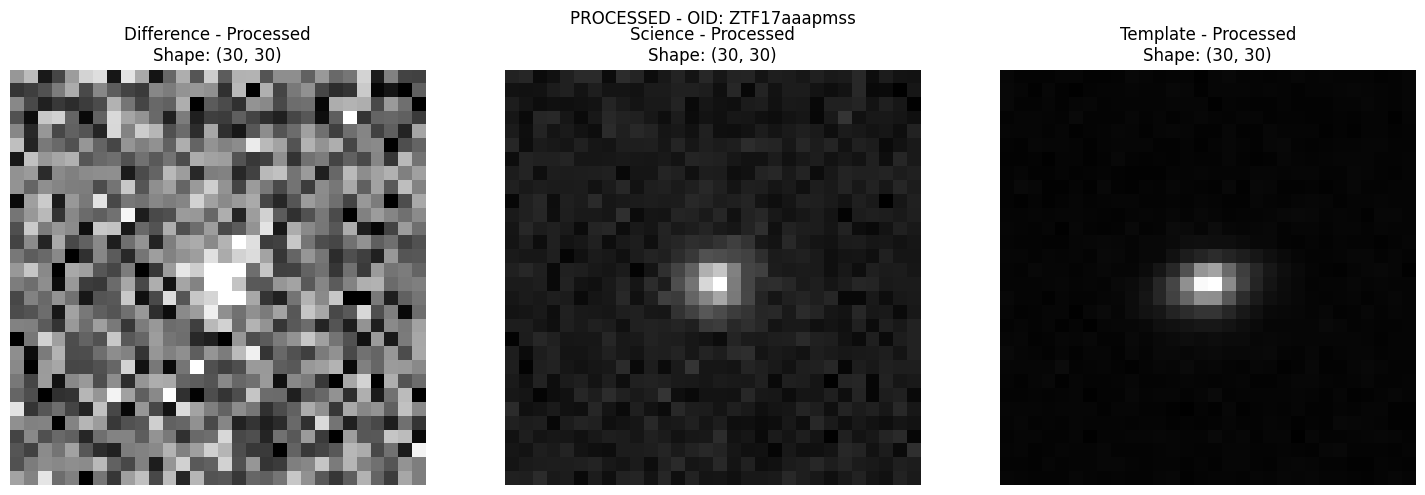

In [22]:
if example_oid in df_merged['oid'].values:
    example_idx = df_merged[df_merged['oid'] == example_oid]['orig_idx'].iloc[0]
    
    plt.figure(figsize=(15, 5))
    titles = ['Difference', 'Science', 'Template']
    for chan in range(3):
        plt.subplot(1, 3, chan + 1)
        plt.imshow(data_np[example_idx, chan], cmap='gray', aspect='equal')
        plt.title(f"{titles[chan]} - Processed\nShape: {data_np[example_idx, chan].shape}")
        plt.axis('off')
    plt.suptitle(f"PROCESSED - OID: {example_oid}")
    plt.tight_layout()
    plt.show()
else:
    print(f"OID {example_oid} no está en los datos filtrados")
    # Usar el primer OID disponible
    example_oid = df_merged['oid'].iloc[0]
    example_idx = df_merged[df_merged['oid'] == example_oid]['orig_idx'].iloc[0]
    
    plt.figure(figsize=(15, 5))
    titles = ['Difference', 'Science', 'Template']
    for chan in range(3):
        plt.subplot(1, 3, chan + 1)
        plt.imshow(data_np[example_idx, chan], cmap='gray', aspect='equal')
        plt.title(f"{titles[chan]} - Processed\nShape: {data_np[example_idx, chan].shape}")
        plt.axis('off')
    plt.suptitle(f"PROCESSED - OID: {example_oid}")
    plt.tight_layout()
    plt.show()

In [23]:
data_tensor   = torch.from_numpy(data_np)
labels_tensor = torch.from_numpy(labels).long()
dataset       = TensorDataset(data_tensor, labels_tensor)

In [25]:
import pickle
filepath = 'stamps_tensor.pkl' 
with open(filepath, 'wb') as f:
        pickle.dump(dataset, f)
print(f"Dataset guardado en {filepath}")

Dataset guardado en stamps_tensor.pkl


In [26]:
print(f"\nTensores creados:")
print(f"- data_tensor shape: {data_tensor.shape}")
print(f"- labels_tensor shape: {labels_tensor.shape}")
print(f"- data_tensor dtype: {data_tensor.dtype}")
print(f"- labels_tensor dtype: {labels_tensor.dtype}")


Tensores creados:
- data_tensor shape: torch.Size([19730, 3, 30, 30])
- labels_tensor shape: torch.Size([19730])
- data_tensor dtype: torch.float32
- labels_tensor dtype: torch.int64


In [27]:
print(f"- NaN en data_tensor: {torch.isnan(data_tensor).any()}")
print(f"- NaN en labels_tensor: {torch.isnan(labels_tensor.float()).any()}")

- NaN en data_tensor: False
- NaN en labels_tensor: False


In [28]:
print(f"- NaN en data_tensor: {torch.isnan(data_tensor).any()}")
print(f"- NaN en labels_tensor: {torch.isnan(labels_tensor.float()).any()}")

- NaN en data_tensor: False
- NaN en labels_tensor: False


In [30]:
# Definimos el loader
loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [31]:
class STAMPCNN(nn.Module):
    """
    CNN para procesar un stamp con 3 canales:
    - channel 0: difference
    - channel 1: science
    - channel 2: template
    Entrada: (batch_size, 3, 63, 63)
    Salida:  (batch_size, out_features)
    """
    def __init__(self, out_features: int = 64, dropout: float = 0.3):
        super().__init__()
        # Convoluciones + batchnorm
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)

        # Poolings
        self.pool = nn.MaxPool2d(2, 2)

        # Aplanamiento y FCs perezosos (LazyLinear infiere in_features)
        self.flatten = nn.Flatten()
        self.fc1     = nn.LazyLinear(128)     # infiere automáticamente in_features
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(128, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Bloque 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        # Bloque 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        # Aplanar y FCs
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [32]:
# Resolucion a entrenar y numero de epochs (bajo para gridsearch)
num_epochs = 3
branch_idx = 0

In [34]:
"""
param_grid = {
    'lr':        [1e-3, 5e-4, 1e-4],
    'batch_size':[8, 16, 32],
    'dropout':   [0.0, 0.3, 0.5],
}
"""
param_grid = {
    'lr':        [1e-3],
    'batch_size':[16, 32],
    'dropout':   [0.3, 0.5],
}

In [35]:
best_auc    = -float('inf')
best_params = None

In [36]:
for fold in range(1,6):
    _, val_idx = get_fold_indices(df_merged, fold)
    lbls = df_merged.loc[df_merged['orig_idx'].isin(val_idx), 'label']
    n_pos = (lbls=='good').sum()
    n_neg = (lbls=='bad').sum()
    print(f"Fold {fold}: +={n_pos}, -={n_neg}")

for lr, batch_size, dropout in product(
        param_grid['lr'],
        param_grid['batch_size'],
        param_grid['dropout']
    ):

    cv_aucs = []

    for fold in range(1, 6):
        # 1) Índices de este fold
        train_idx, val_idx = get_fold_indices(df_merged, fold)

        # 2) DataLoaders
        tr_loader = DataLoader(
            Subset(dataset, train_idx),
            batch_size=batch_size, shuffle=True,
            pin_memory=True, num_workers=2, persistent_workers=True
        )
        vl_loader = DataLoader(
            Subset(dataset, val_idx),
            batch_size=batch_size, shuffle=False,
            pin_memory=True, num_workers=2, persistent_workers=True
        )

        # 3) Modelo y optimizador
        model = STAMPCNN(out_features=1, dropout=dropout).to(device)
        optim = torch.optim.Adam(model.parameters(), lr=lr)
        crit  = nn.BCEWithLogitsLoss()

        # 4) Entrenamiento
        for epoch in range(num_epochs):
            model.train()
            for data, labels in tr_loader:
                x = data.to(device, non_blocking=True)   # ahora (batch,3,63,63)
                y = labels.to(device, non_blocking=True).float()
                optim.zero_grad()
                logits = model(x).squeeze(1)              # (batch,)
                loss   = crit(logits, y)
                loss.backward()
                optim.step()

        # 5) Validación
        model.eval()
        all_logits = []
        all_labels = []
        with torch.no_grad():
            for data, labels in vl_loader:
                x = data.to(device, non_blocking=True)
                logits = model(x).squeeze(1).cpu()      # (batch,)
                all_logits.append(logits)
                all_labels.append(labels)

        # Concatenar todo el fold
        logits = torch.cat(all_logits)               # tensor (M,)
        labels = torch.cat(all_labels)               # tensor (M,)

        # Convertir a probabilidades
        probs = torch.sigmoid(logits)

        # Filtrado de NaN (en labels o en probs)
        mask_valid = (~torch.isnan(labels)) & (~torch.isnan(probs))
        clean_labels = labels[mask_valid].numpy()
        clean_probs  = probs[mask_valid].numpy()

        # Comprobar que hay al menos una clase de cada tipo
        if len(clean_labels) >= 2 and len(np.unique(clean_labels)) == 2:
            auc = roc_auc_score(clean_labels, clean_probs)
        else:
            # Si no hay suficiente variedad, salta este fold
            auc = float('nan')
        cv_aucs.append(auc)
        print(f"Fold {fold}, AUC: {auc:.4f} (lr={lr}, batch={batch_size}, drop={dropout})")

    # 6) Promedio de AUC y actualización de best
    valid_aucs = [a for a in cv_aucs if not np.isnan(a)]
    if valid_aucs:
        mean_auc = sum(valid_aucs) / len(valid_aucs)
    else:
        mean_auc = float('nan')
    print(f"lr={lr}, batch={batch_size}, drop={dropout} → AUC={mean_auc:.4f}")
    if not np.isnan(mean_auc) and mean_auc > best_auc:
        best_auc    = mean_auc
        best_params = (lr, batch_size, dropout)

print("Mejores params STAMPCNN:", best_params, "AUC:", best_auc)

Fold 1: +=2163, -=994
Fold 2: +=2163, -=994
Fold 3: +=2163, -=994
Fold 4: +=2163, -=994
Fold 5: +=2162, -=994
Fold 1, AUC: 0.8054 (lr=0.001, batch=16, drop=0.3)
Fold 2, AUC: 0.8230 (lr=0.001, batch=16, drop=0.3)
Fold 3, AUC: 0.8110 (lr=0.001, batch=16, drop=0.3)
Fold 4, AUC: 0.8043 (lr=0.001, batch=16, drop=0.3)
Fold 5, AUC: 0.8230 (lr=0.001, batch=16, drop=0.3)
lr=0.001, batch=16, drop=0.3 → AUC=0.8134
Fold 1, AUC: 0.7977 (lr=0.001, batch=16, drop=0.5)
Fold 2, AUC: 0.8245 (lr=0.001, batch=16, drop=0.5)
Fold 3, AUC: 0.8148 (lr=0.001, batch=16, drop=0.5)
Fold 4, AUC: 0.7946 (lr=0.001, batch=16, drop=0.5)
Fold 5, AUC: 0.8143 (lr=0.001, batch=16, drop=0.5)
lr=0.001, batch=16, drop=0.5 → AUC=0.8092
Fold 1, AUC: 0.7924 (lr=0.001, batch=32, drop=0.3)
Fold 2, AUC: 0.8146 (lr=0.001, batch=32, drop=0.3)
Fold 3, AUC: 0.8079 (lr=0.001, batch=32, drop=0.3)
Fold 4, AUC: 0.7946 (lr=0.001, batch=32, drop=0.3)
Fold 5, AUC: 0.8147 (lr=0.001, batch=32, drop=0.3)
lr=0.001, batch=32, drop=0.3 → AUC=0.8049